**Physics-Informed Neural Network for the Van der Pol Oscillator**

This notebook starts from `Vanderpol_oscilaltor.ipynb`, generates Van der Pol oscillator data with the same time horizon, initial condition, and true parameter, then trains a PINN to recover both the state trajectory and the oscillator parameter `mu`.


In [1]:
import importlib.util

if importlib.util.find_spec('torch') is None:
    raise ImportError(
        "PyTorch is required for this PINN notebook. Install it in the project venv with:\n"
        "    venv\\Scripts\\python.exe -m pip install torch\n"
        "Then restart the notebook kernel and run again."
    )

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

np.random.seed(7)
torch.manual_seed(7)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cpu


**Generate Van der Pol data**

The simulation uses the same setup as `Vanderpol_oscilaltor.ipynb`: `tf = 5`, `dt = 0.001`, initial state `[1, 1]`, and `mu = 1.2`. A fourth-order Runge-Kutta integrator is used to produce smoother training data.


In [2]:
tf = 5.0
dt = 0.001
steps = int(tf / dt)
t = np.arange(steps, dtype=np.float32).reshape(-1, 1) * dt

mu_true = 1.2
x0 = np.array([1.0, 1.0], dtype=np.float32)

def vanderpol_rhs(state, mu=mu_true):
    x1, x2 = state
    return np.array([
        x2,
        mu * (1.0 - x1**2) * x2 - x1,
    ], dtype=np.float32)

states = np.zeros((steps, 2), dtype=np.float32)
states[0] = x0

for i in range(1, steps):
    s = states[i - 1]
    k1 = vanderpol_rhs(s)
    k2 = vanderpol_rhs(s + 0.5 * dt * k1)
    k3 = vanderpol_rhs(s + 0.5 * dt * k2)
    k4 = vanderpol_rhs(s + dt * k3)
    states[i] = s + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

noise_std = 0.0
measured = states + noise_std * np.random.randn(*states.shape).astype(np.float32)

print('Data shape:', measured.shape)
print('True parameter:', {'mu': mu_true})


Data shape: (5000, 2)
True parameter: {'mu': 1.2}


**Normalize data for stable training**


In [3]:
t_min = t.min()
t_max = t.max()
t_norm = 2.0 * (t - t_min) / (t_max - t_min) - 1.0

y_mean = measured.mean(axis=0, keepdims=True)
y_std = measured.std(axis=0, keepdims=True)
y_norm = (measured - y_mean) / y_std

t_train = torch.tensor(t_norm, dtype=torch.float32, device=device, requires_grad=True)
y_train = torch.tensor(y_norm, dtype=torch.float32, device=device)
y_mean_t = torch.tensor(y_mean, dtype=torch.float32, device=device)
y_std_t = torch.tensor(y_std, dtype=torch.float32, device=device)
dt_norm_dt = torch.tensor(2.0 / (t_max - t_min), dtype=torch.float32, device=device)

print('State mean:', y_mean.ravel())
print('State std:', y_std.ravel())


State mean: [-0.34622252 -0.38894352]
State std: [1.2941693 1.1088538]


**Define the Van der Pol PINN**

`mu` is a positive trainable parameter. It is initialized at the value used in the original WyNDA notebook.


In [4]:
class MLP(nn.Module):
    def __init__(self, in_dim=1, out_dim=2, hidden=64, depth=4):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class VanderpolPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.state_net = MLP()
        self.softplus = nn.Softplus()

        # Store the inverse-Softplus value so the positive physical parameter
        # starts at the value used in the original Van der Pol notebook.
        self.raw_mu = nn.Parameter(self.inverse_softplus(torch.tensor(mu_true)))

    @staticmethod
    def inverse_softplus(value):
        return torch.log(torch.expm1(value))

    def parameters_physical(self):
        mu = self.softplus(self.raw_mu)
        return mu

    def forward(self, t_in):
        y_hat_norm = self.state_net(t_in)
        y_hat = y_mean_t + y_std_t * y_hat_norm
        mu = self.parameters_physical()
        return y_hat_norm, y_hat, mu


model = VanderpolPINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


**Train the PINN**

The data loss fits the measured trajectory. The physics loss enforces the Van der Pol equations at randomly sampled time points.


In [5]:
EPOCHS = 10000
PHYSICS_BATCH = 1024
lambda_data = 1.0
lambda_physics = 0.05

history = []

for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()

    y_hat_norm, _, mu = model(t_train)
    loss_data = torch.mean((y_hat_norm - y_train) ** 2)

    idx = torch.randint(0, steps, (min(PHYSICS_BATCH, steps),), device=device)
    t_phys = t_train[idx].clone().detach().requires_grad_(True)
    _, y_phys, mu = model(t_phys)

    x1 = y_phys[:, 0:1]
    x2 = y_phys[:, 1:2]

    dx1_dt_norm = torch.autograd.grad(x1, t_phys, grad_outputs=torch.ones_like(x1), create_graph=True)[0]
    dx2_dt_norm = torch.autograd.grad(x2, t_phys, grad_outputs=torch.ones_like(x2), create_graph=True)[0]

    dx1_dt = dx1_dt_norm * dt_norm_dt
    dx2_dt = dx2_dt_norm * dt_norm_dt

    r1 = dx1_dt - x2
    r2 = dx2_dt - (mu * (1.0 - x1**2) * x2 - x1)
    loss_physics = torch.mean(r1 ** 2 + r2 ** 2)

    loss = lambda_data * loss_data + lambda_physics * loss_physics
    loss.backward()
    optimizer.step()

    if epoch == 1 or epoch % 500 == 0:
        row = [epoch, loss.item(), loss_data.item(), loss_physics.item(), mu.item()]
        history.append(row)
        print(
            f'Epoch {epoch:5d} | loss={loss.item():.6f} | data={loss_data.item():.6f} | '
            f'physics={loss_physics.item():.6f} | mu={mu.item():.6f}'
        )


Epoch     1 | loss=0.997702 | data=0.991878 | physics=0.116485 | mu=1.200000
Epoch   500 | loss=0.000821 | data=0.000155 | physics=0.013317 | mu=1.152833
Epoch  1000 | loss=0.000472 | data=0.000176 | physics=0.005910 | mu=1.190346
Epoch  1500 | loss=0.000217 | data=0.000065 | physics=0.003056 | mu=1.195610
Epoch  2000 | loss=0.000086 | data=0.000020 | physics=0.001322 | mu=1.197319
Epoch  2500 | loss=0.000210 | data=0.000088 | physics=0.002436 | mu=1.198203
Epoch  3000 | loss=0.000955 | data=0.000586 | physics=0.007367 | mu=1.198532
Epoch  3500 | loss=0.000135 | data=0.000095 | physics=0.000806 | mu=1.199030
Epoch  4000 | loss=0.000317 | data=0.000137 | physics=0.003602 | mu=1.199033
Epoch  4500 | loss=0.000058 | data=0.000036 | physics=0.000444 | mu=1.199143
Epoch  5000 | loss=0.000047 | data=0.000018 | physics=0.000578 | mu=1.198176
Epoch  5500 | loss=0.000013 | data=0.000002 | physics=0.000225 | mu=1.198186
Epoch  6000 | loss=0.000017 | data=0.000007 | physics=0.000210 | mu=1.199112

**Evaluate the learned trajectory and parameter**


In [6]:
model.eval()
with torch.no_grad():
    _, pred_t, mu_hat = model(torch.tensor(t_norm, dtype=torch.float32, device=device))
    pred = pred_t.cpu().numpy()

rmse_measured = np.sqrt(np.mean((measured - pred) ** 2, axis=0))
rmse_clean = np.sqrt(np.mean((states - pred) ** 2, axis=0))

print('RMSE vs measured [x1, x2]:', rmse_measured)
print('RMSE vs clean    [x1, x2]:', rmse_clean)
print('\nTrue parameter:')
print(f'mu={mu_true:.6f}')
print('Learned parameter:')
print(f'mu={mu_hat.item():.6f}')


RMSE vs measured [x1, x2]: [0.00053766 0.00219354]
RMSE vs clean    [x1, x2]: [0.00053766 0.00219354]

True parameter:
mu=1.200000
Learned parameter:
mu=1.199701


**Plot the results**


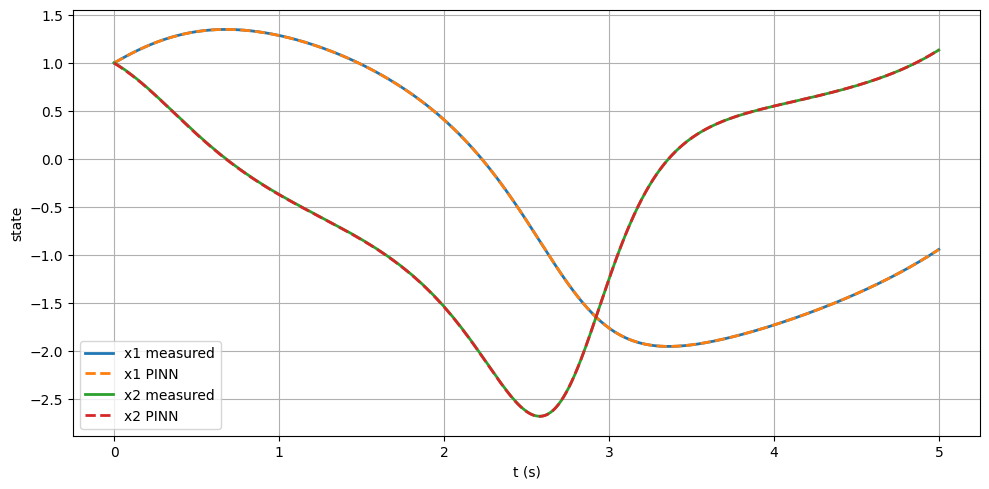

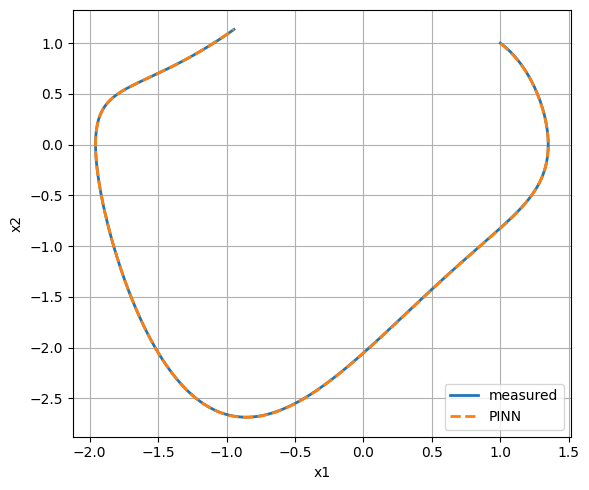

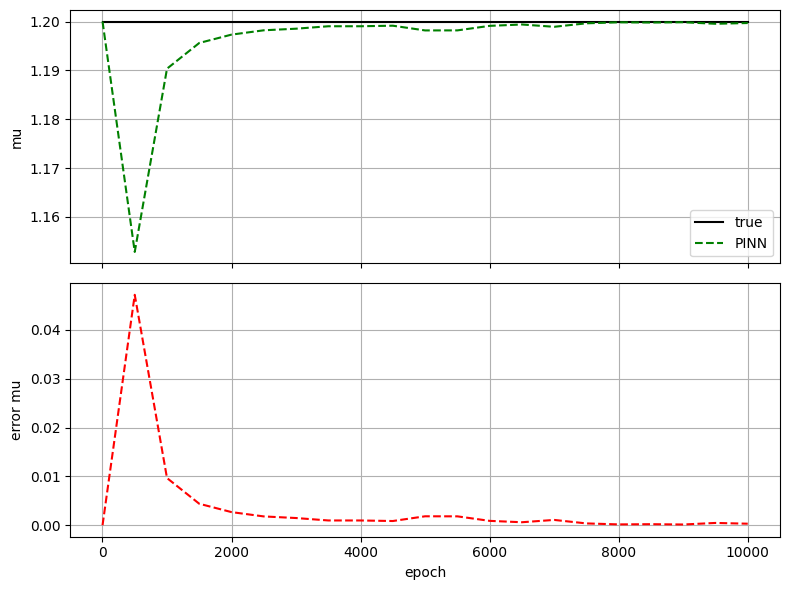

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(t, measured[:, 0], linewidth=2, label='x1 measured')
plt.plot(t, pred[:, 0], '--', linewidth=2, label='x1 PINN')
plt.plot(t, measured[:, 1], linewidth=2, label='x2 measured')
plt.plot(t, pred[:, 1], '--', linewidth=2, label='x2 PINN')
plt.grid(True)
plt.xlabel('t (s)')
plt.ylabel('state')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(measured[:, 0], measured[:, 1], linewidth=2, label='measured')
plt.plot(pred[:, 0], pred[:, 1], '--', linewidth=2, label='PINN')
plt.grid(True)
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.tight_layout()
plt.show()

history_arr = np.array(history)
if len(history_arr) > 0:
    fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    axs[0].plot(history_arr[:, 0], mu_true * np.ones_like(history_arr[:, 0]), 'k', label='true')
    axs[0].plot(history_arr[:, 0], history_arr[:, 4], 'g--', label='PINN')
    axs[0].set_ylabel('mu')
    axs[0].grid(True)
    axs[0].legend()

    axs[1].plot(history_arr[:, 0], mu_true - history_arr[:, 4], 'r--')
    axs[1].set_ylabel('error mu')
    axs[1].set_xlabel('epoch')
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()


**Optional LBFGS refinement**

Set `RUN_LBFGS = True` after Adam training if you want a second optimization pass over all data and physics points.


In [ ]:
RUN_LBFGS = False

if RUN_LBFGS:
    lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.5, max_iter=500, tolerance_grad=1e-7, tolerance_change=1e-9)

    def closure():
        lbfgs.zero_grad()
        y_hat_norm, y_hat, mu = model(t_train)
        loss_data = torch.mean((y_hat_norm - y_train) ** 2)

        x1 = y_hat[:, 0:1]
        x2 = y_hat[:, 1:2]
        dx1_dt = torch.autograd.grad(x1, t_train, grad_outputs=torch.ones_like(x1), create_graph=True)[0] * dt_norm_dt
        dx2_dt = torch.autograd.grad(x2, t_train, grad_outputs=torch.ones_like(x2), create_graph=True)[0] * dt_norm_dt

        r1 = dx1_dt - x2
        r2 = dx2_dt - (mu * (1.0 - x1**2) * x2 - x1)
        loss_physics = torch.mean(r1 ** 2 + r2 ** 2)
        loss = lambda_data * loss_data + lambda_physics * loss_physics
        loss.backward()
        return loss

    final_loss = lbfgs.step(closure)
    print('Final LBFGS loss:', float(final_loss))
